In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style for clean visualizations
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


# ==========================================
# STEP 1: READING THE DATASET
# ==========================================

# Load the dataset
df = pd.read_excel('ABC_Company.xlsx')

# Verify the upload by looking at the first 5 rows
df.head()

,Name,Team,Number,Position,Age,Height,Weight,College,Salary
0,Avery Bradley,Boston Celtics,0,PG,25,2023-02-06 00:00:00,180,Texas,7730337.0
1,Jae Crowder,Boston Celtics,99,SF,25,2023-06-06 00:00:00,235,Marquette,6796117.0
2,John Holland,Boston Celtics,30,SG,27,2023-05-06 00:00:00,205,Boston University,NaN
3,R.J. Hunter,Boston Celtics,28,SG,22,2023-05-06 00:00:00,185,Georgia State,1148640.0
4,Jonas Jerebko,Boston Celtics,8,PF,29,2023-10-06 00:00:00,231,NaN,5000000.0


In [4]:
# ==========================================
# STEP 2: PREPROCESSING (HEIGHT CORRECTION)
# ==========================================
# Task: Correct the "height" column with random integers between 150 and 180

# Generate uniform random floating-point values and round to 1 decimal spot
df['height'] = np.round(np.random.uniform(150, 180, size=len(df)), 1)

# Check the structural properties of your data matrix
print(f"Data dimensions: {df.shape}")
df.head()

Data dimensions: (458, 10)


,Name,Team,Number,Position,Age,Height,Weight,College,Salary,height
0,Avery Bradley,Boston Celtics,0,PG,25,2023-02-06 00:00:00,180,Texas,7730337.0,161.3
1,Jae Crowder,Boston Celtics,99,SF,25,2023-06-06 00:00:00,235,Marquette,6796117.0,153.0
2,John Holland,Boston Celtics,30,SG,27,2023-05-06 00:00:00,205,Boston University,NaN,171.0
3,R.J. Hunter,Boston Celtics,28,SG,22,2023-05-06 00:00:00,185,Georgia State,1148640.0,154.9
4,Jonas Jerebko,Boston Celtics,8,PF,29,2023-10-06 00:00:00,231,NaN,5000000.0,167.0


SG    102
PF    100
PG     92
SF     85
C      79
Name: Position, dtype: int64


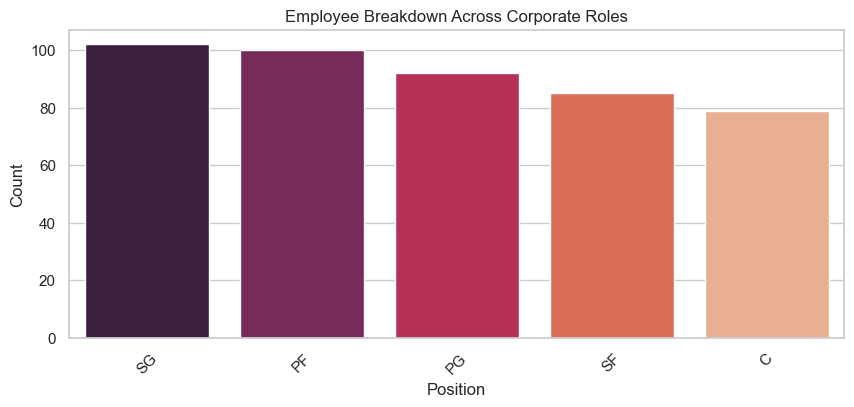

In [5]:
# ==========================================
# STEP 3: ANALYSIS & VISUALS
# ==========================================

# Analysis & Visuals: Position Segregation
# Calculate position metrics
position_counts = df['Position'].value_counts()
print(position_counts)

# Plot corporate tier hierarchy
plt.figure(figsize=(10, 4))
sns.countplot(data=df, x='Position', order=position_counts.index, palette='rocket')
plt.title('Employee Breakdown Across Corporate Roles')
plt.xticks(rotation=45)
plt.ylabel('Count')
plt.show()

Predominant Age Group: 21-30


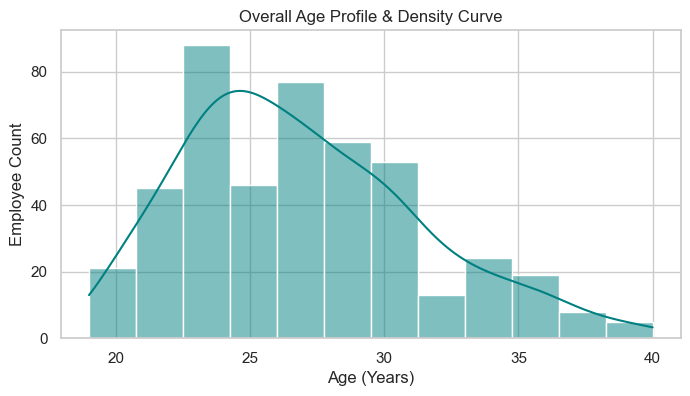

In [6]:
# ==========================================
# STEP 3: ANALYSIS & VISUALS
# ==========================================

# Analysis & Visuals: Position Segregation
# Analysis & Visuals: Predominant Age Group
# Bin ages systematically
age_bins = [20, 30, 40, 50, 60]
age_labels = ['21-30', '31-40', '41-50', '51-60']
df['Age_Group'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels)

# Print the most frequent category
print(f"Predominant Age Group: {df['Age_Group'].value_counts().idxmax()}")

# Plot age distribution profile
plt.figure(figsize=(8, 4))
sns.histplot(df['Age'], bins=12, kde=True, color='teal')
plt.title('Overall Age Profile & Density Curve')
plt.xlabel('Age (Years)')
plt.ylabel('Employee Count')
plt.show()

Highest Spending Team: Cleveland Cavaliers ($106,988,689.0)
Highest Spending Position: C ($466,377,332.0)


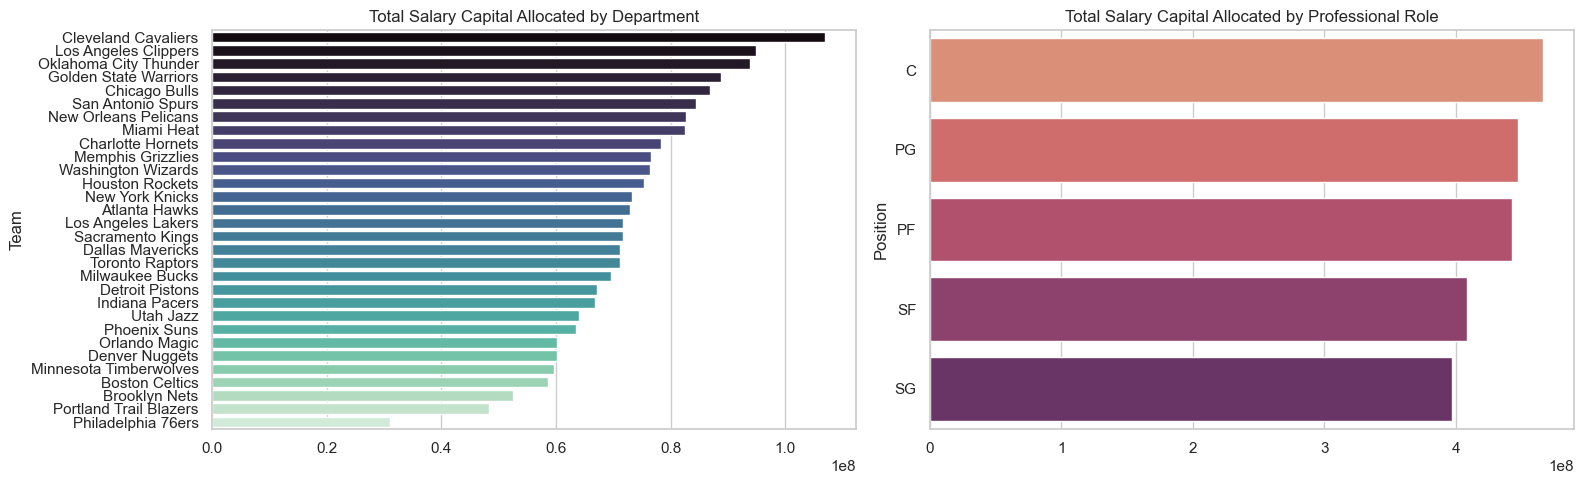

In [7]:
# ==========================================
# STEP 3: ANALYSIS & VISUALS
# ==========================================

# Analysis & Visuals: Highest Salary Expenditure
# Calculate total budget outlays
team_salary = df.groupby('Team')['Salary'].sum().sort_values(ascending=False)
position_salary = df.groupby('Position')['Salary'].sum().sort_values(ascending=False)

print(f"Highest Spending Team: {team_salary.index[0]} (${team_salary.iloc[0]:,})")
print(f"Highest Spending PoANALYSIS & VISUALSsition: {position_salary.index[0]} (${position_salary.iloc[0]:,})")

# Plot financial budget breakdowns side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(x=team_salary.values, y=team_salary.index, ax=axes[0], palette='mako')
axes[0].set_title('Total Salary Capital Allocated by Department')

sns.barplot(x=position_salary.values, y=position_salary.index, ax=axes[1], palette='flare')
axes[1].set_title('Total Salary Capital Allocated by Professional Role')

plt.tight_layout()
plt.show()


Pearson Correlation Coefficient: 0.2140


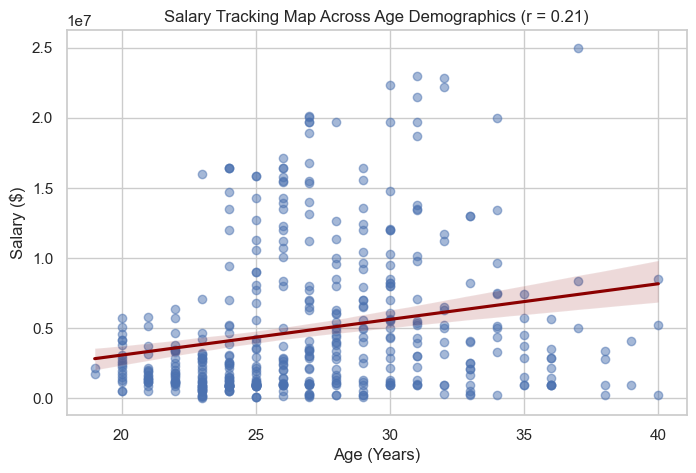

In [8]:
# ==========================================
# STEP 3: ANALYSIS & VISUALS
# ==========================================

# Analysis & Visuals: Age vs. Salary Correlation
# Compute statistical Pearson correlation index
corr_val = df['Age'].corr(df['Salary'])
print(f"Pearson Correlation Coefficient: {corr_val:.4f}")

# Plot trend relationship
plt.figure(figsize=(8, 5))
sns.regplot(data=df, x='Age', y='Salary', scatter_kws={'alpha':0.5}, line_kws={'color':'darkred'})
plt.title(f'Salary Tracking Map Across Age Demographics (r = {corr_val:.2f})')
plt.xlabel('Age (Years)')
plt.ylabel('Salary ($)')
plt.show()